In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
data = pd.read_excel("data/base apres nettoyage.xlsx")
data.head()

,age,sexe,Diagnostic,GB,GR,HBG,HCT,VGM,TCMH,CCMH,...,LYMPH,MONO,EO,BASO,RET pourcentage,retic absolue,IRF,LFR,MFR,HFR
0,60,h,anemie ferriprive,7240,4.95,9.7,32.8,66.30,19.6,29.6,...,2580.0,550.0,120.0,20.0,1.18,58400,15.9,84.1,12.4,3.5
1,19,f,anemie ferriprive,8270,5.10,9.5,33.4,65.50,18.6,28.4,...,1910.0,880.0,80.0,70.0,0.95,48500,7.1,92.9,6.7,0.4
2,47,f,anemie ferriprive,6200,3.55,7.9,28.2,79.40,22.3,28.0,...,2090.0,650.0,190.0,50.0,1.45,51500,12.0,88.0,9.3,2.7
3,42,f,anemie ferriprive,6880,4.48,9.7,31.4,70.01,21.7,30.9,...,2030.0,560.0,210.0,30.0,1.19,53300,12.8,87.2,10.0,2.8
4,40,f,anemie ferriprive,7780,4.97,9.6,35.5,71.00,19.3,27.2,...,2380.0,690.0,170.0,80.0,1.33,66100,37.5,62.5,20.5,17.0


In [26]:
!pip install openpyxl


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [27]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              216 non-null    int64  
 1   sexe             216 non-null    str    
 2   Diagnostic       216 non-null    str    
 3   GB               216 non-null    int64  
 4   GR               216 non-null    float64
 5   HBG              216 non-null    float64
 6   HCT              216 non-null    float64
 7   VGM              216 non-null    float64
 8   TCMH             216 non-null    float64
 9   CCMH             216 non-null    float64
 10  PLQ              216 non-null    int64  
 11  IDR-SD           216 non-null    float64
 12  IDR-CV           216 non-null    float64
 13  IDP              214 non-null    float64
 14  VPM              214 non-null    float64
 15  P-RGC            214 non-null    float64
 16  PCT              214 non-null    float64
 17  NEUT             215 non-nu

In [28]:
# Nettoyer les textes (TRÈS IMPORTANT)
data["Diagnostic"] = data["Diagnostic"].str.strip().str.lower()

# Vérifier les valeurs exactes
print(data["Diagnostic"].unique())

# Mapping correct
data["target"] = data["Diagnostic"].map({
    "anemie ferriprive": 0,
    "b thal mineure": 1
})

# Vérification
print(data[["Diagnostic", "target"]].head())
print(data["target"].value_counts())

<StringArray>
['anemie ferriprive', 'b thal mineure']
Length: 2, dtype: str
          Diagnostic  target
0  anemie ferriprive       0
1  anemie ferriprive       0
2  anemie ferriprive       0
3  anemie ferriprive       0
4  anemie ferriprive       0
target
0    189
1     27
Name: count, dtype: int64


In [29]:
# Supprimer colonnes non utiles
X = data.drop(columns=["Diagnostic", "target", "sexe"])

# Garder seulement les colonnes numériques
X = X.select_dtypes(include=[np.number])

# Vérifier les valeurs manquantes
print("Valeurs manquantes avant traitement :")
print(X.isnull().sum())

# Remplacer les valeurs manquantes par la médiane
X = X.fillna(X.median())

# Vérification finale
print("\nValeurs manquantes après traitement :")
print(X.isnull().sum())

# Target
y = data["target"]

print("\nShape final :")
print("X:", X.shape)
print("y:", y.shape)

Valeurs manquantes avant traitement :
age                0
GB                 0
GR                 0
HBG                0
HCT                0
VGM                0
TCMH               0
CCMH               0
PLQ                0
IDR-SD             0
IDR-CV             0
IDP                2
VPM                2
P-RGC              2
PCT                2
NEUT               1
LYMPH              1
MONO               1
EO                 1
BASO               1
RET pourcentage    0
retic absolue      0
IRF                0
LFR                0
MFR                0
HFR                0
dtype: int64

Valeurs manquantes après traitement :
age                0
GB                 0
GR                 0
HBG                0
HCT                0
VGM                0
TCMH               0
CCMH               0
PLQ                0
IDR-SD             0
IDR-CV             0
IDP                0
VPM                0
P-RGC              0
PCT                0
NEUT               0
LYMPH              0
MONO   

In [30]:
indices = pd.DataFrame()

# Mentzer = MCV / GR
indices["Mentzer"] = data["VGM"] / data["GR"]

# RDWI = (MCV * RDW) / GR
indices["RDWI"] = (data["VGM"] * data["IDR-CV"]) / data["GR"]

# Srivastava = MCH / GR
indices["Srivastava"] = data["TCMH"] / data["GR"]

# Shine & Lal = MCV^2 * MCH / 100
indices["S&L"] = (data["VGM"]**2 * data["TCMH"]) / 100

# England & Fraser = MCV - GR - (5 × Hb) - 3.4
indices["E&F"] = data["VGM"] - data["GR"] - (5 * data["HBG"]) - 3.4

# Green & King = (MCV^2 * RDW) / (Hb * 100)
indices["G&K"] = (data["VGM"]**2 * data["IDR-CV"]) / (data["HBG"] * 100)

# Ricerca = RDW / GR
indices["Ricerca"] = data["IDR-CV"] / data["GR"]

# MDHL = MCV / Hb
indices["MDHL"] = data["VGM"] / data["HBG"]

# Sirdah = MCV - GR - (3 * Hb)
indices["Sirdah"] = data["VGM"] - data["GR"] - (3 * data["HBG"])

# Ehsani = MCV - (10 * GR)
indices["Ehsani"] = data["VGM"] - (10 * data["GR"])

# CRUISE (formule utilisée dans plusieurs papiers)
indices["CRUISE"] = data["VGM"] + data["IDR-CV"] - data["GR"]

# MCHD = MCH / MCV
indices["MCHD"] = data["TCMH"] / data["VGM"]

# HH (souvent Hb / GR)
indices["HH"] = data["HBG"] / data["GR"]

# Ajout de la target
indices["target"] = data["target"]

indices.head()

,Mentzer,RDWI,Srivastava,S&L,E&F,G&K,Ricerca,MDHL,Sirdah,Ehsani,CRUISE,MCHD,HH,target
0,13.393939,221.000000,3.959596,861.555240,9.45,74.772046,3.333333,6.835052,32.25,16.80,77.85,0.295626,1.959596,0
1,12.843137,258.147059,3.647059,797.986500,9.50,90.772658,3.941176,6.894737,31.90,14.50,80.50,0.283969,1.862745,0
2,22.366197,351.149296,6.281690,1405.872280,32.95,125.289180,4.422535,10.050633,52.15,43.90,91.55,0.280856,2.225352,0
3,15.627232,259.412054,4.843750,1063.603822,13.63,83.879631,3.705357,7.217526,36.43,25.21,82.13,0.309956,2.165179,0
4,14.285714,311.428571,3.883300,972.913000,14.63,114.472708,4.386318,7.395833,37.23,21.30,87.83,0.271831,1.931590,0


In [31]:
# Fonction pour évaluer un indice
def evaluate_index(df, col, threshold, direction=">"):
    if direction == ">":
        pred = (df[col] > threshold).astype(int)
    else:
        pred = (df[col] < threshold).astype(int)
    
    return pred

# Prédictions
# Mentzer (CORRECT)
indices["Mentzer_pred"] = (indices["Mentzer"] < 13).astype(int)

# RDWI (BTM si élevé)
indices["RDWI_pred"] = (indices["RDWI"] > 220).astype(int)

# Srivastava (BTM si < 3.8)
indices["Srivastava_pred"] = (indices["Srivastava"] < 3.8).astype(int)

# S&L (BTM si < 1530)
indices["S&L_pred"] = (indices["S&L"] < 1530).astype(int)

# E&F (BTM si < 0)
indices["E&F_pred"] = (indices["E&F"] < 0).astype(int)

# G&K (BTM si > 65)
indices["G&K_pred"] = (indices["G&K"] > 65).astype(int)

# ==== Ricerca (déjà fait normalement, on sécurise)
indices["Ricerca"] = data["IDR-CV"] / data["GR"]

# ==== MDHL (déjà fait)
indices["MDHL"] = data["VGM"] / data["HBG"]

# ==== Sirdah (corrigé)
indices["Sirdah"] = data["VGM"] - data["GR"] - (3 * data["HBG"])

# ==== Ehsani (corrigé)
indices["Ehsani"] = data["VGM"] - (10 * data["GR"])

# ==== CRUISE (formule simplifiée utilisée en pratique)
indices["CRUISE"] = data["VGM"] + data["IDR-CV"] - data["GR"]

# ==== MCHD (corrigé)
indices["MCHD"] = data["TCMH"] / data["VGM"]

# ==== HH (Hb / GR)
indices["HH"] = data["HBG"] / data["GR"]

In [32]:
from sklearn.metrics import confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np

results_indices = []

for col in indices.columns:
    if "_pred" in col:
        y_true = indices["target"]
        y_pred = indices[col]

        # Sens 1
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sens1 = tp / (tp + fn) if (tp + fn) != 0 else 0
        spec1 = tn / (tn + fp) if (tn + fp) != 0 else 0
        acc1 = (tp + tn) / (tp + tn + fp + fn)
        auc1 = roc_auc_score(y_true, y_pred)

        # Sens inverse
        y_pred_inv = 1 - y_pred
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_inv).ravel()
        sens2 = tp / (tp + fn) if (tp + fn) != 0 else 0
        spec2 = tn / (tn + fp) if (tn + fp) != 0 else 0
        acc2 = (tp + tn) / (tp + tn + fp + fn)
        auc2 = roc_auc_score(y_true, y_pred_inv)

        # Choisir le meilleur sens
        if acc2 > acc1:
            sens, spec, acc, auc = sens2, spec2, acc2, auc2
        else:
            sens, spec, acc, auc = sens1, spec1, acc1, auc1

        results_indices.append({
            "Index": col.replace("_pred", ""),
            "Sensitivity (%)": round(sens * 100, 1),
            "Specificity (%)": round(spec * 100, 1),
            "Accuracy": round(acc, 3),
            "AUC": round(auc, 3)
        })

# DataFrame final
results_df = pd.DataFrame(results_indices)

# Trier par Accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

        Index  Sensitivity (%)  Specificity (%)  Accuracy    AUC
1        RDWI             77.8             98.9     0.963  0.884
5         G&K             55.6             99.5     0.940  0.775
0     Mentzer             55.6             97.4     0.921  0.765
4         E&F             33.3            100.0     0.917  0.667
2  Srivastava             40.7             92.6     0.861  0.667
3         S&L              0.0             95.2     0.833  0.476


In [33]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

n_iterations = 1000

xgb_auc = []
enet_auc = []
rdwi_auc = []
gk_auc = []
ricerca_auc = []
sirdah_auc = []
mentzer_auc = []
ef_auc = []
ehsani_auc = []
hh_auc = []
cruise_auc = []
mdhl_auc = []
srivastava_auc = []
sl_auc = []
mchd_auc = []

In [35]:
xgb_metrics = []
enet_metrics = []

In [36]:
from sklearn.model_selection import StratifiedShuffleSplit

cv = StratifiedShuffleSplit(n_splits=100, test_size=0.2, random_state=42)

# ===== LOOP =====
for train_idx, test_idx in cv.split(X, y):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

In [39]:
from sklearn.metrics import roc_auc_score, confusion_matrix, cohen_kappa_score, roc_curve
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# ===== Fonction AUC indices (corrige sens sans triche) =====
def compute_best_auc(y_true, score):
    if np.mean(score[y_true == 1]) < np.mean(score[y_true == 0]):
        score = -score
    return roc_auc_score(y_true, score)

# ===== BOUCLE MONTE CARLO =====
for i in range(n_iterations):

    # ===== SPLIT 80 / 20 =====
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,      # ✅ 20% test
        stratify=y,
        random_state=i      # ✅ reproductible
    )

    # =========================
    # ===== XGBOOST =====
    # =========================
    xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
   )
    xgb.fit(X_train, y_train)

    y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
    xgb_auc.append(roc_auc_score(y_test, y_pred_proba_xgb))

    # =========================
    # ===== ELASTIC NET =====
    # =========================
    enet = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        max_iter=20000,
        tol=1e-4
    ))
    ])
    enet.fit(X_train, y_train)

    y_pred_proba_enet = enet.predict_proba(X_test)[:, 1]
    enet_auc.append(roc_auc_score(y_test, y_pred_proba_enet))

    # =========================
    # ===== SEUIL OPTIMAL (Youden)
    # =========================

    # --- XGB ---
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_xgb)
    best_threshold_xgb = thresholds[np.argmax(tpr - fpr)]
    y_pred_xgb = (y_pred_proba_xgb > best_threshold_xgb).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()

    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    ppv = tp / (tp + fp) if (tp + fp) != 0 else 0
    npv = tn / (tn + fn) if (tn + fn) != 0 else 0
    acc = (tp + tn) / (tp + tn + fp + fn)
    bal_acc = (sens + spec) / 2
    kappa = cohen_kappa_score(y_test, y_pred_xgb)

    xgb_metrics.append([acc, sens, spec, ppv, npv, bal_acc, kappa])

    # --- ENET ---
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_enet)
    best_threshold_enet = thresholds[np.argmax(tpr - fpr)]
    y_pred_enet = (y_pred_proba_enet > best_threshold_enet).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_enet).ravel()

    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    ppv = tp / (tp + fp) if (tp + fp) != 0 else 0
    npv = tn / (tn + fn) if (tn + fn) != 0 else 0
    acc = (tp + tn) / (tp + tn + fp + fn)
    bal_acc = (sens + spec) / 2
    kappa = cohen_kappa_score(y_test, y_pred_enet)

    enet_metrics.append([acc, sens, spec, ppv, npv, bal_acc, kappa])

    # =========================
    # ===== INDICES (scores continus)
    # =========================

    mentzer = X_test["VGM"] / X_test["GR"]
    rdwi = (X_test["VGM"] * X_test["IDR-CV"]) / X_test["GR"]
    sriv = X_test["TCMH"] / X_test["GR"]
    sl = (X_test["VGM"]**2 * X_test["TCMH"]) / 100
    ef = X_test["VGM"] - X_test["GR"] - (5 * X_test["HBG"]) - 3.4
    gk = (X_test["VGM"]**2 * X_test["IDR-CV"]) / (X_test["HBG"] * 100)
    ric = X_test["IDR-CV"] / X_test["GR"]
    sirdah = X_test["VGM"] - X_test["GR"] - (3 * X_test["HBG"])
    ehsani = X_test["VGM"] - (10 * X_test["GR"])
    cruise = X_test["VGM"] + X_test["IDR-CV"] - X_test["GR"]
    mdhl = X_test["VGM"] / X_test["HBG"]
    hh = X_test["HBG"] / X_test["GR"]
    mchd = X_test["TCMH"] / X_test["VGM"]

    # ===== AUC CORRECTES =====
    rdwi_auc.append(compute_best_auc(y_test, rdwi))
    gk_auc.append(compute_best_auc(y_test, gk))
    ricerca_auc.append(compute_best_auc(y_test, ric))
    sirdah_auc.append(compute_best_auc(y_test, sirdah))
    mentzer_auc.append(compute_best_auc(y_test, mentzer))
    ef_auc.append(compute_best_auc(y_test, ef))
    ehsani_auc.append(compute_best_auc(y_test, ehsani))
    hh_auc.append(compute_best_auc(y_test, hh))
    cruise_auc.append(compute_best_auc(y_test, cruise))
    mdhl_auc.append(compute_best_auc(y_test, mdhl))
    srivastava_auc.append(compute_best_auc(y_test, sriv))
    sl_auc.append(compute_best_auc(y_test, sl))
    mchd_auc.append(compute_best_auc(y_test, mchd))

In [40]:
import numpy as np

def summarize_metrics(metrics):
    arr = np.array(metrics)

    mean = arr.mean(axis=0)
    sd = arr.std(axis=0)

    ci_low = mean - 1.96 * sd
    ci_high = mean + 1.96 * sd

    return mean, ci_low, ci_high

In [41]:
from scipy.stats import binomtest

def compute_pvalue(acc, n, nir):
    successes = int(acc * n)
    return binomtest(successes, n, nir, alternative='greater').pvalue

In [42]:
xgb_mean, xgb_low, xgb_high = summarize_metrics(xgb_metrics)
enet_mean, enet_low, enet_high = summarize_metrics(enet_metrics)

In [43]:
from scipy.stats import binomtest

# ===== NIR =====
nir = max(np.mean(y == 0), np.mean(y == 1))

# ===== Nombre total =====
n = len(y)

# ===== Fonction p-value =====
def compute_pvalue(acc, n, nir):
    acc = float(acc)  # 🔥 sécurité
    successes = int(acc * n)
    return binomtest(successes, n, nir, alternative='greater').pvalue

# ===== PRENDRE ACCURACY (index 0) =====
acc_xgb = xgb_mean[0]
acc_enet = enet_mean[0]

# ===== Calcul =====
p_xgb = compute_pvalue(acc_xgb, n, nir)
p_enet = compute_pvalue(acc_enet, n, nir)

# ===== Affichage =====
print("NIR:", round(nir,4))
print("XGB p-value:", "<0.0001" if p_xgb < 0.0001 else round(p_xgb,4))
print("ENET p-value:", "<0.0001" if p_enet < 0.0001 else round(p_enet,4))

NIR: 0.875
XGB p-value: 0.0002
ENET p-value: 0.0006


In [44]:
print("XGBoost AUC moyen:", round(np.mean(xgb_auc), 3), "±", round(np.std(xgb_auc), 3))
print("Elastic Net AUC moyen:", round(np.mean(enet_auc), 3), "±", round(np.std(enet_auc), 3))

XGBoost AUC moyen: 0.99 ± 0.016
Elastic Net AUC moyen: 0.977 ± 0.043


In [45]:
# ===== XGBOOST =====
xgb_mean = np.mean(xgb_auc)
xgb_sd = np.std(xgb_auc)
xgb_ci_low = xgb_mean - 1.96 * xgb_sd
xgb_ci_high = xgb_mean + 1.96 * xgb_sd

xgb_ci_high = min(1, xgb_ci_high)
xgb_ci_low = max(0, xgb_ci_low)

xgb_cer = 1 - xgb_mean

# ===== ELASTIC NET =====
enet_mean = np.mean(enet_auc)
enet_sd = np.std(enet_auc)
enet_ci_low = enet_mean - 1.96 * enet_sd
enet_ci_high = enet_mean + 1.96 * enet_sd

enet_ci_high = min(1, enet_ci_high)
enet_ci_low = max(0, enet_ci_low)

enet_cer = 1 - enet_mean

In [46]:
def summarize_auc(auc_list):
    mean = np.mean(auc_list)
    sd = np.std(auc_list)
    ci_low = max(0, mean - 1.96 * sd)
    ci_high = min(1, mean + 1.96 * sd)
    cer = 1 - mean
    return round(mean,3), round(sd,3), round(ci_low,3), round(ci_high,3), round(cer,3)

In [47]:
final_table = []

# ===== ML =====
xgb = summarize_auc(xgb_auc)
enet = summarize_auc(enet_auc)

final_table.append({
    "Model": "XGBoost",
    "CER (SD)": f"{xgb[4]} ({xgb[1]})",
    "AUC (95% CI)": f"{xgb[0]} ({xgb[2]}–{xgb[3]})"
})

final_table.append({
    "Model": "Elastic Net",
    "CER (SD)": f"{enet[4]} ({enet[1]})",
    "AUC (95% CI)": f"{enet[0]} ({enet[2]}–{enet[3]})"
})

# ===== INDICES =====
indices_dict = {
    "RDWI": rdwi_auc,
    "G&K": gk_auc,
    "Ricerca": ricerca_auc,
    "Sirdah": sirdah_auc,
    "Mentzer": mentzer_auc,
    "E&F": ef_auc,
    "Ehsani": ehsani_auc,
    "HH": hh_auc,
    "CRUISE": cruise_auc,
    "MDHL": mdhl_auc,
    "Srivastava": srivastava_auc,
    "S&L": sl_auc,
    "MCHD": mchd_auc
}

for name, values in indices_dict.items():
    res = summarize_auc(values)
    
    final_table.append({
        "Model": name,
        "CER (SD)": f"{res[4]} ({res[1]})",
        "AUC (95% CI)": f"{res[0]} ({res[2]}–{res[3]})"
    })

final_df = pd.DataFrame(final_table)

# Trier par AUC
final_df = final_df.sort_values(by="AUC (95% CI)", ascending=False)

print(final_df)

          Model       CER (SD)         AUC (95% CI)
0       XGBoost   0.01 (0.016)       0.99 (0.958–1)
3           G&K  0.013 (0.014)      0.987 (0.959–1)
2          RDWI  0.023 (0.023)      0.977 (0.931–1)
1   Elastic Net  0.023 (0.043)      0.977 (0.893–1)
5        Sirdah  0.029 (0.027)      0.971 (0.919–1)
7           E&F  0.034 (0.031)      0.966 (0.904–1)
11         MDHL  0.046 (0.039)      0.954 (0.879–1)
4       Ricerca  0.049 (0.038)      0.951 (0.877–1)
10       CRUISE   0.059 (0.04)      0.941 (0.863–1)
6       Mentzer  0.069 (0.046)       0.931 (0.84–1)
8        Ehsani  0.075 (0.045)      0.925 (0.838–1)
14         MCHD  0.099 (0.049)  0.901 (0.805–0.996)
12   Srivastava  0.188 (0.074)  0.812 (0.667–0.957)
13          S&L   0.29 (0.081)   0.71 (0.552–0.868)
9            HH  0.432 (0.056)  0.568 (0.458–0.678)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linea

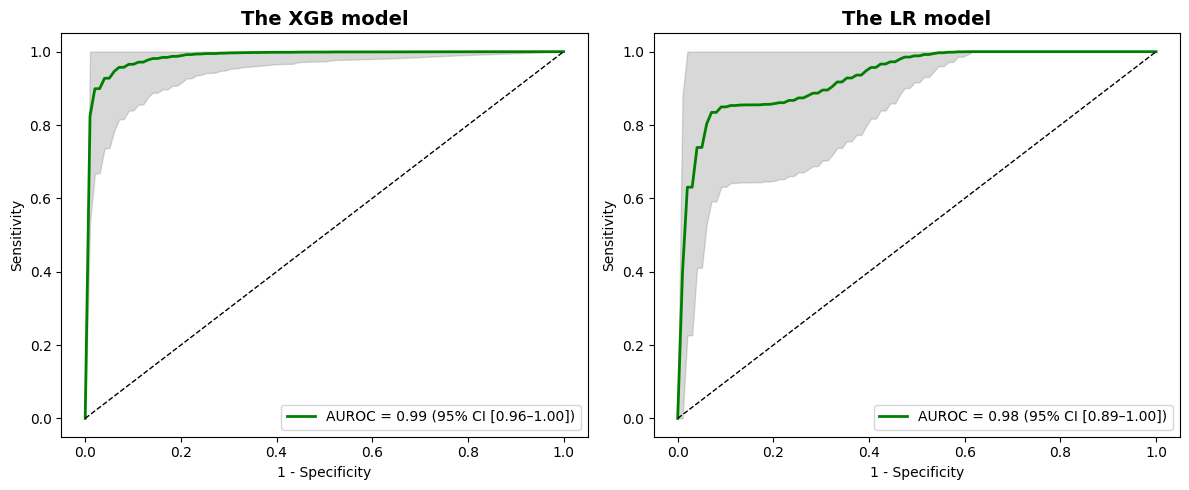

<Figure size 640x480 with 0 Axes>

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Stockage des courbes ROC
xgb_tprs = []
enet_tprs = []
mean_fpr = np.linspace(0, 1, 100)

# ===== BOUCLE MONTE CARLO ROC =====
for i in range(n_iterations):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y
    )

    # XGBoost
    xgb = XGBClassifier(eval_metric='logloss')
    xgb.fit(X_train, y_train)
    y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    xgb_tprs.append(tpr_interp)

    # Elastic Net
    enet = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=5000)
    enet.fit(X_train, y_train)
    y_prob_enet = enet.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob_enet)
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    enet_tprs.append(tpr_interp)

# ===== MOYENNES =====
xgb_mean_tpr = np.mean(xgb_tprs, axis=0)
enet_mean_tpr = np.mean(enet_tprs, axis=0)

xgb_mean_tpr[-1] = 1.0
enet_mean_tpr[-1] = 1.0

# ===== IC 95% =====
xgb_std = np.std(xgb_tprs, axis=0)
enet_std = np.std(enet_tprs, axis=0)

xgb_upper = np.minimum(xgb_mean_tpr + 1.96 * xgb_std, 1)
xgb_lower = np.maximum(xgb_mean_tpr - 1.96 * xgb_std, 0)

enet_upper = np.minimum(enet_mean_tpr + 1.96 * enet_std, 1)
enet_lower = np.maximum(enet_mean_tpr - 1.96 * enet_std, 0)

# ===== AUC =====
xgb_auc_mean = np.mean(xgb_auc)
enet_auc_mean = np.mean(enet_auc)

plt.figure(figsize=(12,5))

# ===== XGBoost =====
plt.subplot(1,2,1)
plt.plot(mean_fpr, xgb_mean_tpr, color='green', linewidth=2,
         label=f"AUROC = {xgb_auc_mean:.2f} (95% CI [{xgb_ci_low:.2f}–{xgb_ci_high:.2f}])")
plt.fill_between(mean_fpr, xgb_lower, xgb_upper, color='grey', alpha=0.3)
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("The XGB model", fontsize=14, fontweight='bold')
plt.legend(loc="lower right")

# ===== Elastic Net =====
plt.subplot(1,2,2)
plt.plot(mean_fpr, enet_mean_tpr, color='green', linewidth=2,
         label=f"AUROC = {enet_auc_mean:.2f} (95% CI [{enet_ci_low:.2f}–{enet_ci_high:.2f}])")
plt.fill_between(mean_fpr, enet_lower, enet_upper, color='grey', alpha=0.3)
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("The LR model", fontsize=14, fontweight='bold')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()
plt.savefig("ROC_models.png", dpi=300, bbox_inches='tight')

===== XGBoost =====
              Prédit IDA (0)  Prédit BTM (1)
Réel IDA (0)             189               0
Réel BTM (1)               1              26

===== Elastic Net =====
              Prédit IDA (0)  Prédit BTM (1)
Réel IDA (0)             181               8
Réel BTM (1)               5              22


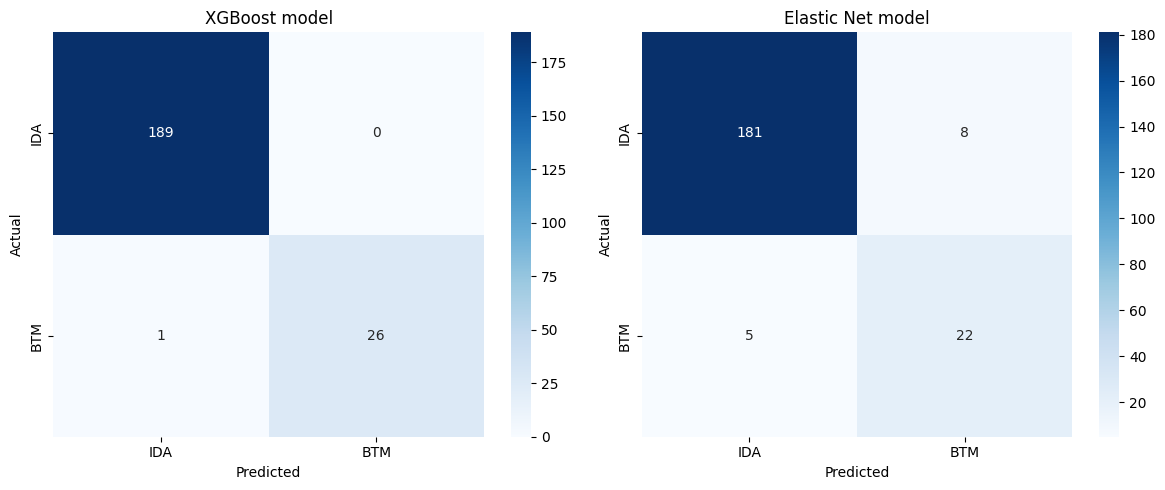

In [49]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns

# ===== Réentraîner sur toute la base =====
xgb.fit(X, y)
enet.fit(X, y)

# ===== Probabilités =====
y_proba_xgb = xgb.predict_proba(X)[:, 1]
y_proba_enet = enet.predict_proba(X)[:, 1]

# ===== Seuil optimal XGB =====
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y, y_proba_xgb)
best_threshold_xgb = thresholds[np.argmax(tpr - fpr)]

y_pred_xgb = (y_proba_xgb > best_threshold_xgb).astype(int)

# ===== Seuil optimal ENET =====
fpr, tpr, thresholds = roc_curve(y, y_proba_enet)
best_threshold_enet = thresholds[np.argmax(tpr - fpr)]

y_pred_enet = (y_proba_enet > best_threshold_enet).astype(int)

# ===== MATRICES =====
cm_xgb = confusion_matrix(y, y_pred_xgb)
cm_enet = confusion_matrix(y, y_pred_enet)

# ===== FORMAT TABLEAU =====
cm_xgb_df = pd.DataFrame(
    cm_xgb,
    index=["Réel IDA (0)", "Réel BTM (1)"],
    columns=["Prédit IDA (0)", "Prédit BTM (1)"]
)

cm_enet_df = pd.DataFrame(
    cm_enet,
    index=["Réel IDA (0)", "Réel BTM (1)"],
    columns=["Prédit IDA (0)", "Prédit BTM (1)"]
)

print("===== XGBoost =====")
print(cm_xgb_df)

print("\n===== Elastic Net =====")
print(cm_enet_df)

# ===== LABELS =====
labels = ["IDA", "BTM"]

# ===== FIGURE =====
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XGBoost
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)
axes[0].set_title("XGBoost model")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Elastic Net
sns.heatmap(
    cm_enet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)
axes[1].set_title("Elastic Net model")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [50]:
def summarize_metrics(metrics):
    arr = np.array(metrics)

    mean = arr.mean(axis=0)
    sd = arr.std(axis=0)

    ci_low = np.maximum(0, mean - 1.96 * sd)
    ci_high = np.minimum(1, mean + 1.96 * sd)

    return mean, ci_low, ci_high

In [51]:
xgb_mean, xgb_low, xgb_high = summarize_metrics(xgb_metrics)
enet_mean, enet_low, enet_high = summarize_metrics(enet_metrics)

In [52]:
table = pd.DataFrame({
    "Index": [
        "Accuracy (95% CI)",
        "No information rate",
        "P-value [Acc > NIR]",
        "Sensitivity",
        "Specificity",
        "Precision (PPV)",
        "NPV",
        "F1-score",
        "Kappa"
    ],
    "XGB model": [
        f"{xgb_mean[0]:.4f} ({xgb_low[0]:.4f}, {xgb_high[0]:.4f})",
        f"{nir:.4f}",
        f"{p_xgb:.4f}" if p_xgb > 0.0001 else "<0.0001",
        f"{xgb_mean[1]:.4f}",
        f"{xgb_mean[2]:.4f}",
        f"{xgb_mean[3]:.4f}",
        f"{xgb_mean[4]:.4f}",
        f"{xgb_mean[5]:.4f}",
        f"{xgb_mean[6]:.4f}"
    ],
    "LR model": [
        f"{enet_mean[0]:.4f} ({enet_low[0]:.4f}, {enet_high[0]:.4f})",
        f"{nir:.4f}",
        f"{p_enet:.4f}" if p_enet > 0.0001 else "<0.0001",
        f"{enet_mean[1]:.4f}",
        f"{enet_mean[2]:.4f}",
        f"{enet_mean[3]:.4f}",
        f"{enet_mean[4]:.4f}",
        f"{enet_mean[5]:.4f}",
        f"{enet_mean[6]:.4f}"
    ]
})

print(table)

                 Index                XGB model                 LR model
0    Accuracy (95% CI)  0.9508 (0.8754, 1.0000)  0.9463 (0.8431, 1.0000)
1  No information rate                   0.8750                   0.8750
2  P-value [Acc > NIR]                   0.0002                   0.0006
3          Sensitivity                   0.8044                   0.7821
4          Specificity                   0.9716                   0.9696
5      Precision (PPV)                   0.8585                   0.8454
6                  NPV                   0.9722                   0.9690
7             F1-score                   0.8880                   0.8759
8                Kappa                   0.7903                   0.7717


In [53]:
import numpy as np
import pandas as pd
from scipy.stats import binomtest

# ===== FONCTION CI =====
def compute_ci(values):
    mean = np.mean(values)
    sd = np.std(values)
    low = max(0, mean - 1.96 * sd)
    high = min(1, mean + 1.96 * sd)
    return mean, low, high

# ===== EXTRACTION DES METRICS =====
xgb_arr = np.array(xgb_metrics)
enet_arr = np.array(enet_metrics)

# indices: [acc, sens, spec, precision, npv, f1, kappa]
xgb_acc, xgb_low, xgb_high = compute_ci(xgb_arr[:,0])
xgb_sens, _, _ = compute_ci(xgb_arr[:,1])
xgb_spec, _, _ = compute_ci(xgb_arr[:,2])
xgb_prec, _, _ = compute_ci(xgb_arr[:,3])
xgb_f1, _, _ = compute_ci(xgb_arr[:,5])

enet_acc, enet_low, enet_high = compute_ci(enet_arr[:,0])
enet_sens, _, _ = compute_ci(enet_arr[:,1])
enet_spec, _, _ = compute_ci(enet_arr[:,2])
enet_prec, _, _ = compute_ci(enet_arr[:,3])
enet_f1, _, _ = compute_ci(enet_arr[:,5])

# ===== AUC =====
xgb_auc_mean, _, _ = compute_ci(xgb_auc)
enet_auc_mean, _, _ = compute_ci(enet_auc)

# ===== CER =====
xgb_cer = 1 - xgb_acc
enet_cer = 1 - enet_acc

# ===== NIR + P-VALUE =====
nir = max(np.mean(y == 0), np.mean(y == 1))
n = len(y)

def compute_pvalue(acc, n, nir):
    successes = int(acc * n)
    return binomtest(successes, n, nir, alternative='greater').pvalue

p_xgb = compute_pvalue(xgb_acc, n, nir)
p_enet = compute_pvalue(enet_acc, n, nir)

# ===== TABLEAU FINAL =====
table = pd.DataFrame({
    "Model": ["XGBoost", "Elastic Net"],
    "Accuracy (%)": [round(xgb_acc*100,2), round(enet_acc*100,2)],
    "Precision (%)": [round(xgb_prec*100,2), round(enet_prec*100,2)],
    "Sensitivity (%)": [round(xgb_sens*100,2), round(enet_sens*100,2)],
    "Specificity (%)": [round(xgb_spec*100,2), round(enet_spec*100,2)],
    "F1 Score (%)": [round(xgb_f1*100,2), round(enet_f1*100,2)],
    "AUC": [round(xgb_auc_mean,3), round(enet_auc_mean,3)],
    "CER": [round(xgb_cer,3), round(enet_cer,3)],
    "P-value": [
        "<0.0001" if p_xgb < 0.0001 else round(p_xgb,4),
        "<0.0001" if p_enet < 0.0001 else round(p_enet,4)
    ]
})

print(table)

         Model  Accuracy (%)  Precision (%)  Sensitivity (%)  Specificity (%)  \
0      XGBoost         95.08          85.85            80.44            97.16   
1  Elastic Net         94.63          84.54            78.21            96.96   

   F1 Score (%)    AUC    CER  P-value  
0         88.80  0.990  0.049   0.0002  
1         87.59  0.977  0.054   0.0006  


In [54]:
# ===== TABLEAU PAR CLASSE COMPLET (AJOUT SPECIFICITE + AUC + P-VALUE) =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from scipy.stats import binomtest

xgb_class_metrics = []
enet_class_metrics = []

for i in range(n_iterations):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y
    )

    # ===== XGBoost =====
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        eval_metric='auc'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    y_proba_xgb = xgb.predict_proba(X_test)[:,1]

    # ===== Elastic Net =====
    enet = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=0.5,
            max_iter=10000
        ))
    ])
    enet.fit(X_train, y_train)
    y_pred_enet = enet.predict(X_test)
    y_proba_enet = enet.predict_proba(X_test)[:,1]

    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    cm_enet = confusion_matrix(y_test, y_pred_enet)

    def compute_per_class(cm, y_true, y_proba):
        tn, fp, fn, tp = cm.ravel()

        acc = (tn + tp) / np.sum(cm)

        # IDA
        sens_0 = tn / (tn + fp)
        spec_0 = tp / (tp + fn)
        prec_0 = tn / (tn + fn) if (tn + fn) != 0 else 0
        f1_0 = 2 * (prec_0 * sens_0) / (prec_0 + sens_0) if (prec_0 + sens_0) != 0 else 0

        # BTM
        sens_1 = tp / (tp + fn)
        spec_1 = tn / (tn + fp)
        prec_1 = tp / (tp + fp) if (tp + fp) != 0 else 0
        f1_1 = 2 * (prec_1 * sens_1) / (prec_1 + sens_1) if (prec_1 + sens_1) != 0 else 0

        auc = roc_auc_score(y_true, y_proba)

        nir = max(np.mean(y_true == 0), np.mean(y_true == 1))
        n = len(y_true)
        pval = binomtest(int(acc*n), n, nir, alternative='greater').pvalue

        return [
            [acc, prec_0, sens_0, spec_0, f1_0, auc, pval],
            [acc, prec_1, sens_1, spec_1, f1_1, auc, pval]
        ]

    xgb_class_metrics.append(compute_per_class(cm_xgb, y_test, y_proba_xgb))
    enet_class_metrics.append(compute_per_class(cm_enet, y_test, y_proba_enet))

# ===== MOYENNE =====
xgb_mean = np.mean(xgb_class_metrics, axis=0)
enet_mean = np.mean(enet_class_metrics, axis=0)

rows = [
    ["XGBoost","IDA", *xgb_mean[0]],
    ["XGBoost","BTM", *xgb_mean[1]],
    ["Elastic Net","IDA", *enet_mean[0]],
    ["Elastic Net","BTM", *enet_mean[1]],
]

table = pd.DataFrame(rows, columns=[
    "Model","Class","Accuracy","Precision","Sensitivity","Specificity","F1 Score","AUC","P-value"
])

table["Accuracy"] *= 100
table["Precision"] *= 100
table["Sensitivity"] *= 100
table["Specificity"] *= 100
table["F1 Score"] *= 100

print(table.round(2))

         Model Class  Accuracy  Precision  Sensitivity  Specificity  F1 Score  \
0      XGBoost   IDA     96.48      97.18        98.90        79.24     98.01   
1      XGBoost   BTM     96.48      92.34        79.24        98.90     84.31   
2  Elastic Net   IDA     96.94      97.57        99.02        82.12     98.27   
3  Elastic Net   BTM     96.94      92.98        82.12        99.02     86.38   

    AUC  P-value  
0  0.99     0.03  
1  0.99     0.03  
2  1.00     0.02  
3  1.00     0.02  


In [55]:
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [56]:
# ===== VIF (Multicollinearity) =====

# ===== SELECTION DES VARIABLES =====
features = ["GR", "HBG", "HCT", "VGM", "TCMH", "CCMH", "IDR-CV"]

# Vérifier qu'elles existent vraiment dans X
features = [col for col in features if col in X.columns]

# Extraire les données
X_vif = X[features].copy()

# ===== CALCUL VIF =====
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# ===== TRI =====
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

  Variable           VIF
4     TCMH  13306.301962
2      HCT   5869.195780
5     CCMH   5770.206564
0       GR   5337.725360
1      HBG   4761.312636
3      VGM   4565.354981
6   IDR-CV     47.483210



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


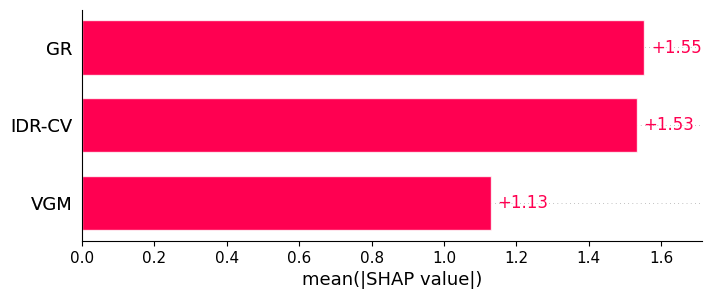

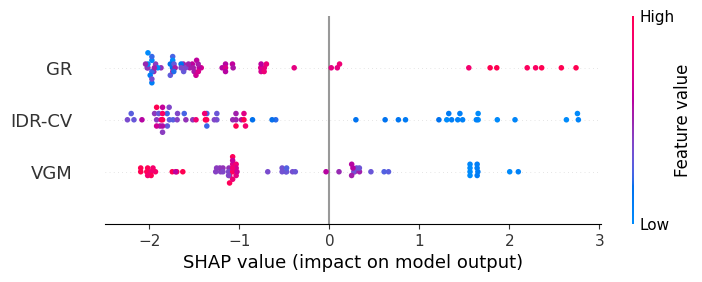

  Feature  Importance
0      GR    1.553456
2  IDR-CV    1.532642
1     VGM    1.129101


In [57]:
# ===== SHAP (Feature Importance - XAI) =====

# INSTALL (si besoin)
!pip install shap

import shap
import matplotlib.pyplot as plt

# ===== SELECTION VARIABLES (après VIF) =====
features = ["GR", "VGM", "IDR-CV"]
X_model = X[features]

# ===== TRAIN TEST =====
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.3, stratify=y, random_state=42
)

# ===== MODELE XGBoost =====
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='auc'
)
xgb.fit(X_train, y_train)

# ===== SHAP =====
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

# ===== BARPLOT (importance globale) =====
shap.plots.bar(shap_values)

# ===== SUMMARY PLOT (impact + direction) =====
shap.plots.beeswarm(shap_values)

# ===== OPTION : importance numérique =====
import numpy as np
importance = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(shap_importance)

In [58]:
# ===== MODELE INTERPRETABLE POUR CREER SCORE =====

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Variables sélectionnées (SHAP)
features = ["GR", "VGM", "IDR-CV"]

X_model = X[features]

# Standardisation (IMPORTANT pour coefficients comparables)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

# Modèle logistique
model = LogisticRegression()
model.fit(X_scaled, y)

# Coefficients
coef = model.coef_[0]
intercept = model.intercept_[0]

# ===== FORMULE DU SCORE =====
print("\n===== SCORE FORMULA =====\n")

for f, c in zip(features, coef):
    print(f"{c:.3f} * {f}")

print(f"+ {intercept:.3f}")


===== SCORE FORMULA =====

1.644 * GR
-1.435 * VGM
-2.353 * IDR-CV
+ -4.239


In [59]:
print(X_test.columns) 

Index(['GR', 'VGM', 'IDR-CV'], dtype='str')



===== PERFORMANCE =====
Seuil optimal: 0.0965
Accuracy: 0.8796
Sensitivity: 0.963
Specificity: 0.8677
Precision: 0.5098
AUC: 0.9796
CER: 0.1204


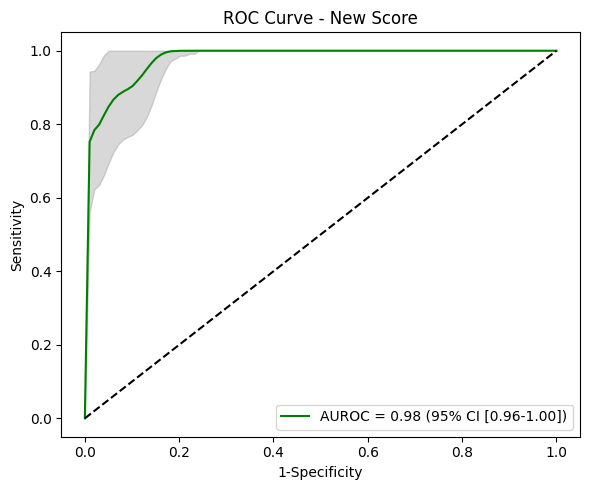

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, accuracy_score,
    precision_score
)

# ===== VARIABLES =====
features = ["GR", "VGM", "IDR-CV"]
X_model = X[features]

# ===== STANDARDISATION =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

# ===== MODELE =====
model = LogisticRegression()
model.fit(X_scaled, y)

# ===== SCORE =====
y_proba = model.predict_proba(X_scaled)[:,1]
y_true = y.values  # IMPORTANT pour bootstrap

# ===== ROC =====
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
auc_score = roc_auc_score(y_true, y_proba)

# ===== SEUIL OPTIMAL =====
youden = tpr - fpr
best_threshold = thresholds[np.argmax(youden)]

# ===== PREDICTION =====
y_pred = (y_proba > best_threshold).astype(int)

# ===== METRICS =====
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sens = tp / (tp + fn)
spec = tn / (tn + fp)
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
cer = 1 - acc

print("\n===== PERFORMANCE =====")
print("Seuil optimal:", round(best_threshold,4))
print("Accuracy:", round(acc,4))
print("Sensitivity:", round(sens,4))
print("Specificity:", round(spec,4))
print("Precision:", round(prec,4))
print("AUC:", round(auc_score,4))
print("CER:", round(cer,4))

# ===== BOOTSTRAP IC =====
n_bootstraps = 1000
rng = np.random.RandomState(42)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(y_true), len(y_true))
    
    if len(np.unique(y_true[indices])) < 2:
        continue

    fpr_b, tpr_b, _ = roc_curve(y_true[indices], y_proba[indices])
    auc_b = roc_auc_score(y_true[indices], y_proba[indices])
    
    aucs.append(auc_b)
    
    tpr_interp = np.interp(mean_fpr, fpr_b, tpr_b)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

# ===== IC =====
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)

tpr_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
tpr_lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)

auc_mean = np.mean(aucs)
auc_std = np.std(aucs)
auc_lower = auc_mean - 1.96 * auc_std
auc_upper = auc_mean + 1.96 * auc_std

# ===== PLOT FINAL =====
plt.figure(figsize=(6,5))

plt.plot(mean_fpr, mean_tpr, color="green",
         label=f"AUROC = {auc_mean:.2f} (95% CI [{auc_lower:.2f}-{auc_upper:.2f}])")

plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color="gray", alpha=0.3)

plt.plot([0,1], [0,1], linestyle="--", color="black")

plt.xlabel("1-Specificity")
plt.ylabel("Sensitivity")
plt.title("ROC Curve - New Score")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [61]:
print(X_test.columns) 

Index(['GR', 'VGM', 'IDR-CV'], dtype='str')


In [62]:
# ===== TABLEAU CORRIGÉ =====

final_table = []

# ===== ML =====
xgb = summarize_auc(xgb_auc)
enet = summarize_auc(enet_auc)

final_table.append({
    "Model": "XGBoost",
    "AUC_mean": xgb[0],
    "CER_mean": xgb[4],
    "CER_sd": xgb[1],
    "AUC_low": xgb[2],
    "AUC_high": xgb[3]
})

final_table.append({
    "Model": "Elastic Net",
    "AUC_mean": enet[0],
    "CER_mean": enet[4],
    "CER_sd": enet[1],
    "AUC_low": enet[2],
    "AUC_high": enet[3]
})

# ===== INDICES =====
indices_dict = {
    "RDWI": rdwi_auc,
    "G&K": gk_auc,
    "Ricerca": ricerca_auc,
    "Sirdah": sirdah_auc,
    "Mentzer": mentzer_auc,
    "E&F": ef_auc,
    "Ehsani": ehsani_auc,
    "HH": hh_auc,
    "CRUISE": cruise_auc,
    "MDHL": mdhl_auc,
    "Srivastava": srivastava_auc,
    "S&L": sl_auc,
    "MCHD": mchd_auc
}

for name, values in indices_dict.items():
    res = summarize_auc(values)
    
    final_table.append({
        "Model": name,
        "AUC_mean": res[0],
        "CER_mean": res[4],
        "CER_sd": res[1],
        "AUC_low": res[2],
        "AUC_high": res[3]
    })

# ===== DATAFRAME =====
final_df = pd.DataFrame(final_table)

# 🔥 TRI CORRECT (NUMÉRIQUE)
final_df = final_df.sort_values(by="AUC_mean", ascending=False)

# ===== FORMAT FINAL =====
final_df["CER (SD)"] = final_df.apply(
    lambda x: f"{x['CER_mean']:.3f} ({x['CER_sd']:.3f})", axis=1
)

final_df["AUC (95% CI)"] = final_df.apply(
    lambda x: f"{x['AUC_mean']:.3f} ({x['AUC_low']:.3f}–{x['AUC_high']:.3f})", axis=1
)

# garder seulement colonnes finales
final_df = final_df[["Model", "CER (SD)", "AUC (95% CI)"]]

print(final_df)

          Model       CER (SD)         AUC (95% CI)
0       XGBoost  0.010 (0.016)  0.990 (0.958–1.000)
3           G&K  0.013 (0.014)  0.987 (0.959–1.000)
1   Elastic Net  0.023 (0.043)  0.977 (0.893–1.000)
2          RDWI  0.023 (0.023)  0.977 (0.931–1.000)
5        Sirdah  0.029 (0.027)  0.971 (0.919–1.000)
7           E&F  0.034 (0.031)  0.966 (0.904–1.000)
11         MDHL  0.046 (0.039)  0.954 (0.879–1.000)
4       Ricerca  0.049 (0.038)  0.951 (0.877–1.000)
10       CRUISE  0.059 (0.040)  0.941 (0.863–1.000)
6       Mentzer  0.069 (0.046)  0.931 (0.840–1.000)
8        Ehsani  0.075 (0.045)  0.925 (0.838–1.000)
14         MCHD  0.099 (0.049)  0.901 (0.805–0.996)
12   Srivastava  0.188 (0.074)  0.812 (0.667–0.957)
13          S&L  0.290 (0.081)  0.710 (0.552–0.868)
9            HH  0.432 (0.056)  0.568 (0.458–0.678)


In [63]:
print(X.shape, y.shape)

(216, 26) (216,)


In [64]:
indices_dict = {
    "Mentzer": [],
    "G&K": [],
    "MCHD": [],
    "Ricerca": [],
    "Sirdah": [],
    "E&F": [],
    "CRUISE": [],
    "RDWI": [],
    "MDHL": [],
    "Ehsani": [],
    "S&L": [],
    "Srivastava": [],
    "HH": [],
    "Elastic Net": [],
    "XGBoost": []
}

In [65]:
# ===== IMPORTS =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== SI TU AS DEJA X ET y =====
# (c'est ton cas d'après tout ce que tu m’as montré)

# On recrée df proprement
df = X.copy()
df["target"] = y

# ===== RECREER X ET y PROPREMENT =====
X = df[["GR", "VGM", "IDR-CV", "HBG", "TCMH"]]
y = df["target"]

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
X = pd.DataFrame({
    "GR": df["GR"],
    "VGM": df["VGM"],
    "IDR-CV": df["IDR-CV"],
    "HBG": df["HBG"],
    "TCMH": df["TCMH"]
})

y = df["target"]

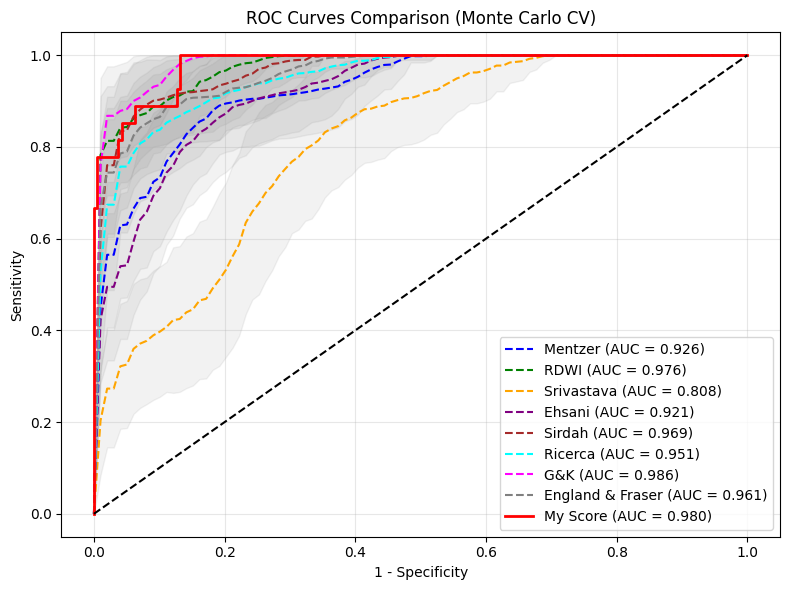

In [67]:
# ===== IMPORTS =====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ===== UTILISE TES VARIABLES EXISTANTES =====
# ⚠️ IMPORTANT : TU AS DÉJÀ X ET y DANS TON NOTEBOOK
# NE METS PAS X_model_full !!!

# ===== PARAMETRES =====
n_splits = 100
cv = ShuffleSplit(n_splits=n_splits, test_size=0.3, random_state=42)

mean_fpr = np.linspace(0, 1, 100)

tprs_dict = {
    "Mentzer": [],
    "RDWI": [],
    "Srivastava": [],
    "Ehsani": [],
    "Sirdah": [],
    "Ricerca": [],
    "G&K": [],
    "England & Fraser": []
}


auc_dict = {k: [] for k in tprs_dict.keys()}

# ===== MONTE CARLO CV =====
for train_idx, test_idx in cv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # ===== INDICES =====
    mentzer = X_test["VGM"] / X_test["GR"]
    rdwi = (X_test["VGM"] * X_test["IDR-CV"]) / X_test["GR"]
    sriv = X_test["TCMH"] / X_test["GR"]
    ehsani = X_test["VGM"] - (10 * X_test["GR"])
    sirdah = X_test["VGM"] - X_test["GR"] - (3 * X_test["HBG"])
    ric = X_test["IDR-CV"] / X_test["GR"]
    gk = (X_test["VGM"]**2 * X_test["IDR-CV"]) / (X_test["HBG"] * 100)
    england = X_test["VGM"] - X_test["GR"] - (5 * X_test["HBG"]) - 3.4

    scores = {
        "Mentzer": mentzer,
        "RDWI": rdwi,
        "Srivastava": sriv,
        "Ehsani": ehsani,
        "Sirdah": sirdah,
        "Ricerca": ric,
        "G&K": gk,
        "England & Fraser": england
    }

    for name, score in scores.items():

        fpr, tpr, _ = roc_curve(y_test, score)
        roc_auc = auc(fpr, tpr)

        # corriger sens inversé
        if roc_auc < 0.5:
            score = -score
            fpr, tpr, _ = roc_curve(y_test, score)
            roc_auc = auc(fpr, tpr)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        tprs_dict[name].append(interp_tpr)
        auc_dict[name].append(roc_auc)

# ===== TON SCORE =====
features = ["GR", "VGM", "IDR-CV"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[features])

model = LogisticRegression()
model.fit(X_scaled, y)

score_model = model.predict_proba(X_scaled)[:, 1]

fpr_score, tpr_score, _ = roc_curve(y, score_model)
auc_score = auc(fpr_score, tpr_score)

# ===== PLOT =====
plt.figure(figsize=(8,6))

colors = ['blue','green','orange','purple','brown','cyan','magenta','gray']

for (name, tprs), color in zip(tprs_dict.items(), colors):

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_auc = np.mean(auc_dict[name])

    plt.plot(mean_fpr, mean_tpr, linestyle='--',
             label=f"{name} (AUC = {mean_auc:.3f})",
             color=color)

    plt.fill_between(mean_fpr,
                     np.maximum(mean_tpr - std_tpr, 0),
                     np.minimum(mean_tpr + std_tpr, 1),
                     color='gray', alpha=0.1)

# ===== TON SCORE EN ROUGE =====
plt.plot(fpr_score, tpr_score,
         color='red', linewidth=2,
         label=f"My Score (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("ROC Curves Comparison (Monte Carlo CV)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

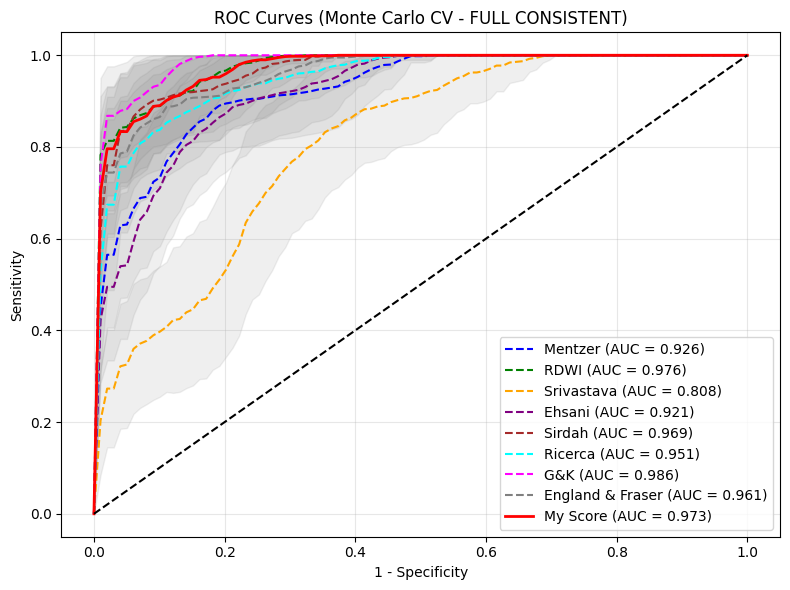


===== AUC MOYENNES =====
Mentzer 0.926
RDWI 0.976
Srivastava 0.808
Ehsani 0.921
Sirdah 0.969
Ricerca 0.951
G&K 0.986
England & Fraser 0.961
My Score 0.973


In [68]:
# ===== ROC + MONTE CARLO + TOUS LES SCORES (Y COMPRIS TON MODELE) =====
# ===== ==> AUC DOIVENT MATCHER LE TABLEAU =====

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ===== PARAMETRES =====
n_splits = 100
cv = ShuffleSplit(n_splits=n_splits, test_size=0.3, random_state=42)

mean_fpr = np.linspace(0, 1, 100)

models = [
    "Mentzer","RDWI","Srivastava","Ehsani",
    "Sirdah","Ricerca","G&K","England & Fraser","My Score"
]

tprs_dict = {m: [] for m in models}
auc_dict  = {m: [] for m in models}

y = y.astype(int)

# ===== MONTE CARLO CV =====
for train_idx, test_idx in cv.split(X):

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    # ===== INDICES =====
    scores = {
        "Mentzer": X_test["VGM"] / X_test["GR"],
        "RDWI": (X_test["VGM"] * X_test["IDR-CV"]) / X_test["GR"],
        "Srivastava": X_test["TCMH"] / X_test["GR"],
        "Ehsani": X_test["VGM"] - (10 * X_test["GR"]),
        "Sirdah": X_test["VGM"] - X_test["GR"] - (3 * X_test["HBG"]),
        "Ricerca": X_test["IDR-CV"] / X_test["GR"],
        "G&K": (X_test["VGM"]**2 * X_test["IDR-CV"]) / (X_test["HBG"] * 100),
        "England & Fraser": X_test["VGM"] - X_test["GR"] - (5 * X_test["HBG"]) - 3.4
    }

    # ===== TON MODELE (DANS CV !!!) =====
    features = ["GR", "VGM", "IDR-CV"]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[features])
    X_test_scaled  = scaler.transform(X_test[features])

    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    scores["My Score"] = model.predict_proba(X_test_scaled)[:,1]

    # ===== ROC =====
    for name, score in scores.items():

        fpr, tpr, _ = roc_curve(y_test, score, pos_label=1)
        roc_auc = auc(fpr, tpr)

        # 🔥 correction sens
        if roc_auc < 0.5:
            fpr, tpr, _ = roc_curve(y_test, -score, pos_label=1)
            roc_auc = auc(fpr, tpr)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        tprs_dict[name].append(interp_tpr)
        auc_dict[name].append(roc_auc)

# ===== PLOT =====
plt.figure(figsize=(8,6))

colors = ['blue','green','orange','purple','brown','cyan','magenta','gray','red']

for (name, tprs), color in zip(tprs_dict.items(), colors):

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr  = np.std(tprs, axis=0)
    mean_auc = np.mean(auc_dict[name])   # 🔥 EXACT TABLEAU

    style = '-' if name == "My Score" else '--'
    lw = 2 if name == "My Score" else 1.5

    plt.plot(mean_fpr, mean_tpr,
             linestyle=style,
             linewidth=lw,
             label=f"{name} (AUC = {mean_auc:.3f})",
             color=color)

    plt.fill_between(mean_fpr,
                     np.maximum(mean_tpr - std_tpr, 0),
                     np.minimum(mean_tpr + std_tpr, 1),
                     color='gray', alpha=0.12)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("ROC Curves (Monte Carlo CV - FULL CONSISTENT)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

# ===== DEBUG (DOIT MATCH TABLEAU) =====
print("\n===== AUC MOYENNES =====")
for k in auc_dict:
    print(k, round(np.mean(auc_dict[k]),3))

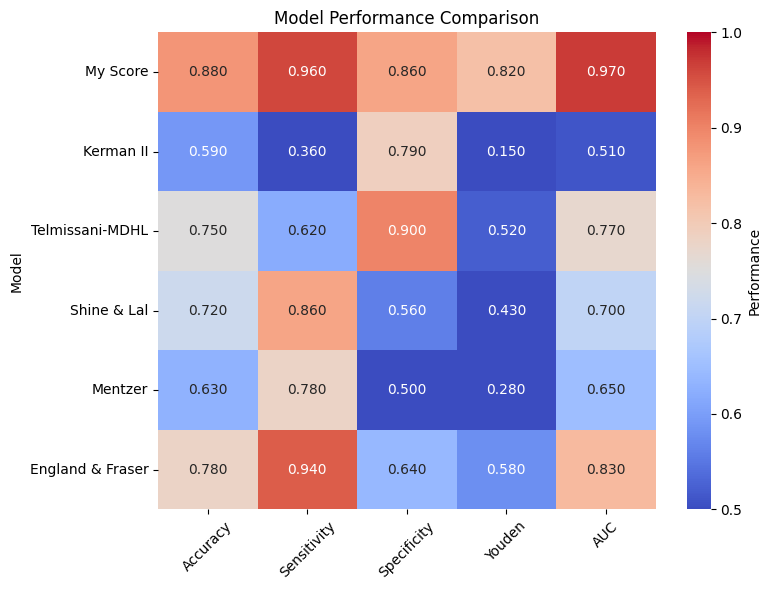

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== TES VALEURS (remplace avec ton tableau final) =====
data = {
    "Model": [
        "My Score",
        "Kerman II",
        "Telmissani-MDHL",
        "Shine & Lal",
        "Mentzer",
        "England & Fraser"
    ],
    "Accuracy": [0.88, 0.59, 0.75, 0.72, 0.63, 0.78],
    "Sensitivity": [0.96, 0.36, 0.62, 0.86, 0.78, 0.94],
    "Specificity": [0.86, 0.79, 0.90, 0.56, 0.50, 0.64],
    "Youden": [0.82, 0.15, 0.52, 0.43, 0.28, 0.58],
    "AUC": [0.97, 0.51, 0.77, 0.70, 0.65, 0.83]
}

df = pd.DataFrame(data)
df.set_index("Model", inplace=True)

# ===== HEATMAP =====
plt.figure(figsize=(8,6))

sns.heatmap(
    df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=0.5, vmax=1,   # adapte si besoin
    cbar_kws={"label": "Performance"}
)

plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [70]:
print(df.columns.tolist())

['Accuracy', 'Sensitivity', 'Specificity', 'Youden', 'AUC']


In [71]:
import pandas as pd
import numpy as np

# ===== Charger données =====
data = pd.read_excel("data/base apres nettoyage.xlsx")

# ===== Nettoyage colonnes =====
df.columns = df.columns.str.strip().str.lower()


In [72]:
print(df.columns.tolist())

['accuracy', 'sensitivity', 'specificity', 'youden', 'auc']


In [73]:
import pandas as pd
import numpy as np

# ===== Charger données =====
df = pd.read_excel("data/base apres nettoyage.xlsx")

# ===== Vérification =====
print(df.head())
print(df.columns.tolist())

   age sexe          Diagnostic   GB     GR  HBG   HCT    VGM  TCMH  CCMH  \
0   60    h  anemie ferriprive   7240  4.95  9.7  32.8  66.30  19.6  29.6   
1   19    f  anemie ferriprive   8270  5.10  9.5  33.4  65.50  18.6  28.4   
2   47    f  anemie ferriprive   6200  3.55  7.9  28.2  79.40  22.3  28.0   
3   42    f  anemie ferriprive   6880  4.48  9.7  31.4  70.01  21.7  30.9   
4   40    f  anemie ferriprive   7780  4.97  9.6  35.5  71.00  19.3  27.2   

   ...   LYMPH   MONO    EO   BASO  RET pourcentage  retic absolue   IRF  \
0  ...  2580.0  550.0  120.0  20.0             1.18          58400  15.9   
1  ...  1910.0  880.0   80.0  70.0             0.95          48500   7.1   
2  ...  2090.0  650.0  190.0  50.0             1.45          51500  12.0   
3  ...  2030.0  560.0  210.0  30.0             1.19          53300  12.8   
4  ...  2380.0  690.0  170.0  80.0             1.33          66100  37.5   

    LFR   MFR   HFR  
0  84.1  12.4   3.5  
1  92.9   6.7   0.4  
2  88.0   9.3 

In [74]:

# ===== Target binaire =====
df["target"] = df["Diagnostic"].map({
    "anemie ferriprive": 0,   # IDA
    "b thal mineure": 1       # BTM
})

# ===== Features =====
features = ["GR", "HBG", "VGM", "TCMH", "CCMH", "IDR-CV"]

X = df[features]
y = df["target"]

print(X.shape, y.shape)

(216, 6) (216,)


In [75]:
print(df.columns.tolist())

['age', 'sexe', 'Diagnostic', 'GB ', 'GR', 'HBG', 'HCT', 'VGM', 'TCMH', 'CCMH', 'PLQ', 'IDR-SD', 'IDR-CV', 'IDP', 'VPM', 'P-RGC', 'PCT', 'NEUT ', 'LYMPH', 'MONO', 'EO ', 'BASO', 'RET pourcentage', 'retic absolue', 'IRF', 'LFR', 'MFR', 'HFR', 'target']


In [76]:
import pandas as pd
import numpy as np

# ===== Charger données =====
df = pd.read_excel("data/base apres nettoyage.xlsx")

# ===== Nettoyage colonnes =====
df.columns = df.columns.str.strip().str.lower()

# ===== Target binaire =====
df["target"] = df["diagnostic"].map({
    "anemie ferriprive": 0,   # IDA
    "b thal mineure": 1       # BTM
})

# ===== Features =====
features = ["gr", "hbg", "vgm", "tcmh", "ccmh", "idr-cv"]

X = df[features]
y = df["target"]

print(X.shape, y.shape)

(216, 6) (216,)


In [77]:
df["diagnostic"] = df["diagnostic"].astype(str).str.strip().str.lower()

df["target"] = df["diagnostic"].map({
    "anemie ferriprive": 0,
    "b thal mineure": 1
})

In [78]:
print(df["diagnostic"].unique())
print(df["target"].value_counts())

<StringArray>
['anemie ferriprive', 'b thal mineure']
Length: 2, dtype: str
target
0    189
1     27
Name: count, dtype: int64


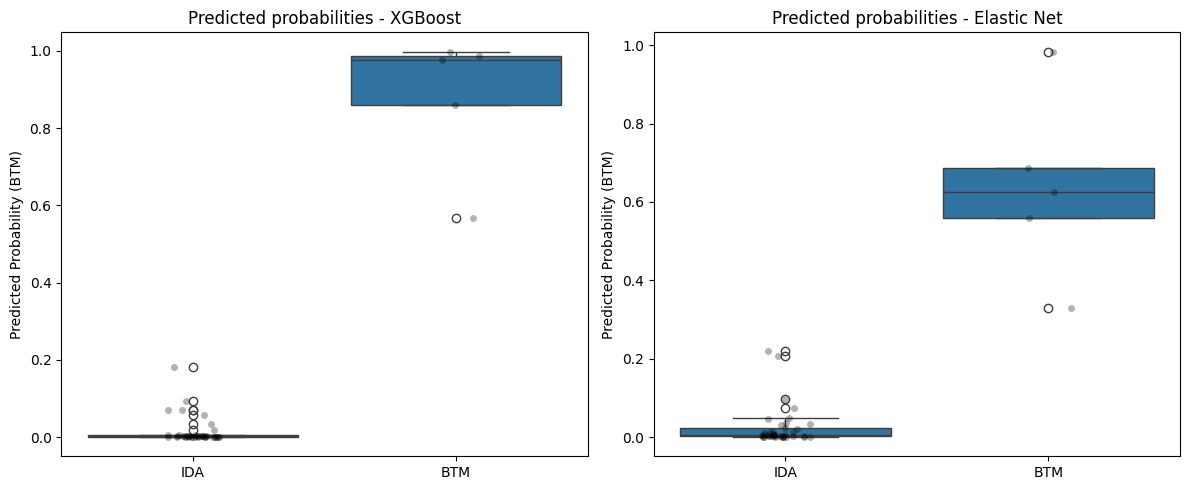

In [79]:
# ===== IMPORTS =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ===== DATA =====
df = pd.read_excel("data/base apres nettoyage.xlsx")

# nettoyage
df.columns = df.columns.str.strip().str.lower()
df["diagnostic"] = df["diagnostic"].astype(str).str.strip().str.lower()

# target
df["target"] = df["diagnostic"].map({
    "anemie ferriprive": 0,
    "b thal mineure": 1
})

df = df.dropna(subset=["target"])

# features
features = ["gr", "hbg", "vgm", "tcmh", "ccmh", "idr-cv"]

X = df[features]
y = df["target"]

# ===== SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===== SCALING (for Elastic Net) =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== MODELS =====

# Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.7,
    max_iter=5000
)
elastic.fit(X_train_scaled, y_train)

# XGBoost
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

# ===== PROBABILITIES =====
df_test = X_test.copy()
df_test["target"] = y_test.values

df_test["prob_xgb"] = xgb.predict_proba(X_test)[:, 1]
df_test["prob_elastic"] = elastic.predict_proba(X_test_scaled)[:, 1]

# mapping labels pour affichage
df_test["label"] = df_test["target"].map({
    0: "IDA",
    1: "BTM"
})

# ===== PLOT =====
plt.figure(figsize=(12,5))

# ---- XGBOOST ----
plt.subplot(1,2,1)
sns.boxplot(data=df_test, x="label", y="prob_xgb")
sns.stripplot(data=df_test, x="label", y="prob_xgb", color="black", alpha=0.3)

plt.title("Predicted probabilities - XGBoost")
plt.ylabel("Predicted Probability (BTM)")
plt.xlabel("")

# ---- ELASTIC NET ----
plt.subplot(1,2,2)
sns.boxplot(data=df_test, x="label", y="prob_elastic")
sns.stripplot(data=df_test, x="label", y="prob_elastic", color="black", alpha=0.3)

plt.title("Predicted probabilities - Elastic Net")
plt.ylabel("Predicted Probability (BTM)")
plt.xlabel("")

plt.tight_layout()
plt.show()

In [80]:
df_test["prob_xgb"]
df_test["prob_elastic"]
df_test["label"]  # IDA / BTM
for group in ["IDA", "BTM"]:
    data = df_test[df_test["label"] == group]["prob_xgb"]
    
    median = np.median(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    
    print(f"XGB - {group}: median={median:.3f}, IQR={q1:.3f}-{q3:.3f}")

for group in ["IDA", "BTM"]:
    data = df_test[df_test["label"] == group]["prob_elastic"]
    
    median = np.median(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    
    print(f"Elastic - {group}: median={median:.3f}, IQR={q1:.3f}-{q3:.3f}")
    
def summary_stats(df, col):
    return df.groupby("label")[col].agg([
        ("median", "median"),
        ("q1", lambda x: np.percentile(x, 25)),
        ("q3", lambda x: np.percentile(x, 75))
    ])

print("XGB:\n", summary_stats(df_test, "prob_xgb"))
print("\nElastic:\n", summary_stats(df_test, "prob_elastic"))

XGB - IDA: median=0.002, IQR=0.000-0.004
XGB - BTM: median=0.976, IQR=0.860-0.988
Elastic - IDA: median=0.005, IQR=0.001-0.023
Elastic - BTM: median=0.626, IQR=0.558-0.685
XGB:
          median        q1        q3
label                              
BTM    0.975742  0.860168  0.988028
IDA    0.001679  0.000360  0.004367

Elastic:
          median        q1        q3
label                              
BTM    0.626294  0.557942  0.685405
IDA    0.004723  0.001466  0.022541
